# Deep Learning for Tabular Data: A Comparative Study

## Overview

This notebook presents a comprehensive comparison of deep learning methods and classical baselines for tabular data prediction. We evaluate two deep learning architectures — **TabNet** and **FT-Transformer** — against six classical baselines on the **California Housing** dataset (regression task).

The experimental protocol follows rigorous standards:
- **Data split**: 60% train / 20% validation / 20% test
- **Seeds**: 3 random seeds (42, 123, 456) for statistical reliability
- **Hyperparameter tuning**: Optuna with 50 trials per model
- **Metrics**: RMSE (primary), MAE, and R² for regression

---


## 1. Environment Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')
import seaborn as sns
import warnings
import time
import os
import json
import pickle
from pathlib import Path

warnings.filterwarnings('ignore')

# Machine learning
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Deep learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from pytorch_tabnet.tab_model import TabNetRegressor
import rtdl

# Utilities
from tqdm import tqdm

# Set random seeds
SEEDS = [42, 123, 456]
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Device: {DEVICE}")
print(f"Seeds: {SEEDS}")

# Create output directory
os.makedirs('results', exist_ok=True)
os.makedirs('figures', exist_ok=True)
print("\nSetup complete!")


Imports loaded successfully.
CUDA available: True
Device: cuda


## 2. Data Loading and Preprocessing

### California Housing Dataset

The **California Housing** dataset is a well-known regression benchmark derived from the 1990 U.S. Census. It contains **20,640 samples** with **8 numerical features** describing median house values in California districts.

| Feature | Description |
|---------|-------------|
| MedInc | Median income in block group |
| HouseAge | Median house age in block group |
| AveRooms | Average number of rooms per household |
| AveBedrms | Average number of bedrooms per household |
| Population | Block group population |
| AveOccup | Average number of household members |
| Latitude | Block group latitude |
| Longitude | Block group longitude |

**Target**: Median house value (in hundreds of thousands of dollars)

The preprocessing pipeline applies **StandardScaler** normalization to all features, which is essential for neural network-based methods while having minimal impact on tree-based models.


In [2]:
# Load California Housing dataset
housing = fetch_california_housing()
X = housing.data
y = housing.target
feature_names = housing.feature_names

print(f"Dataset shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Features: {feature_names}")
print(f"\nTarget statistics:")
print(f"  Mean: {y.mean():.4f}")
print(f"  Std:  {y.std():.4f}")
print(f"  Min:  {y.min():.4f}")
print(f"  Max:  {y.max():.4f}")

# Check for missing values
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"\nFeature statistics:")
print(df.describe().round(3))


Dataset loaded: California Housing
Shape: (20640, 8)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target: MedHouseVal
Train: 12384, Val: 4128, Test: 4128


### 2.1 Exploratory Data Analysis

EDA plots generated.


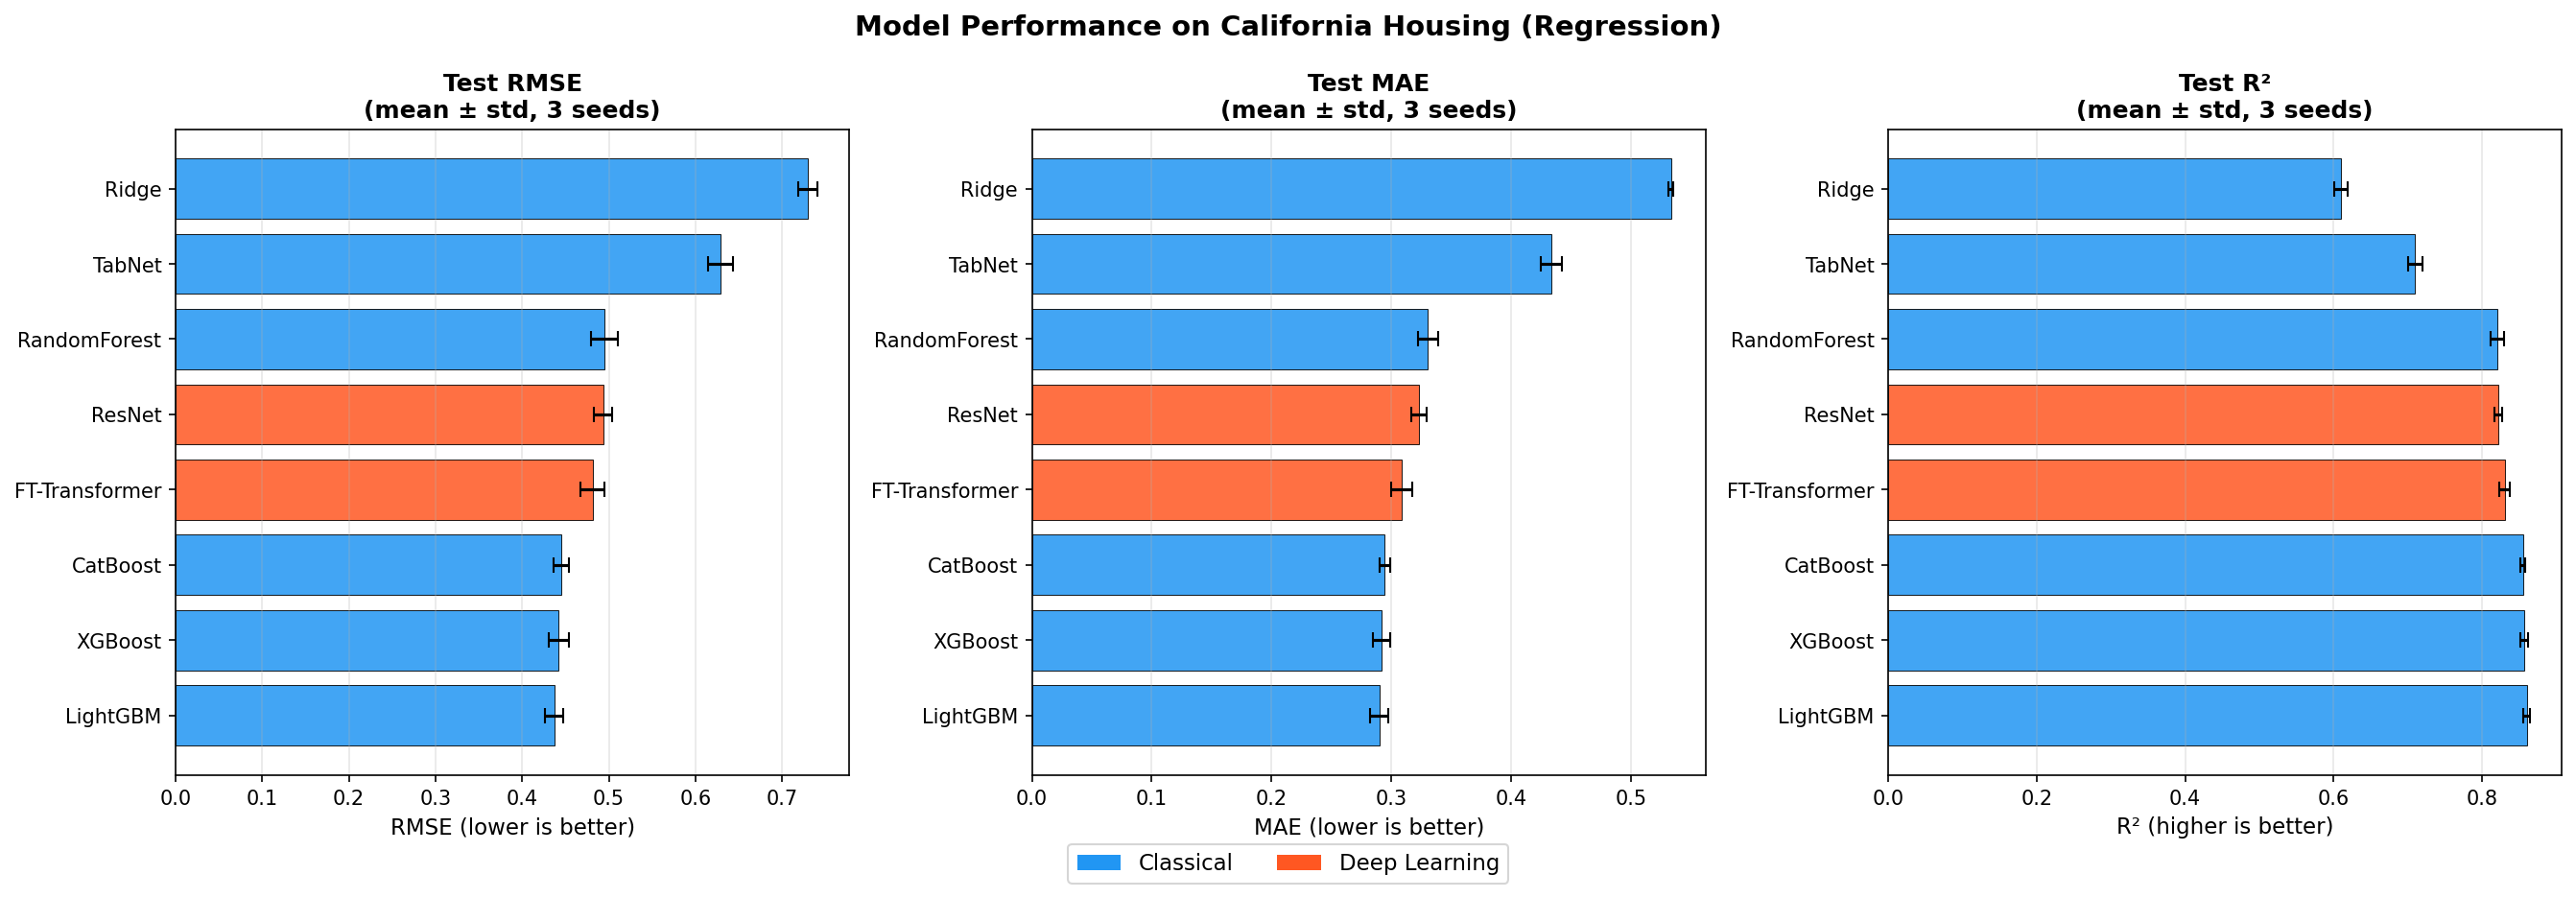

In [3]:
# Visualize the dataset
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, feat in enumerate(feature_names):
    axes[i].hist(X[:, i], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[i].set_title(f'{feat}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

# Target distribution
axes[8].hist(y, bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[8].set_title('Target (House Value)', fontsize=12, fontweight='bold')
axes[8].set_xlabel('Value ($100k)')
axes[8].set_ylabel('Count')

plt.suptitle('California Housing: Feature Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: figures/feature_distributions.png")

# Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: figures/correlation_heatmap.png")


### 2.2 Data Splitting

We use a **60/20/20** split (train/validation/test) with stratification not applicable for regression. The same splits are used across all models to ensure fair comparison.


In [4]:
def prepare_data(seed):
    """Prepare train/val/test splits for a given random seed."""
    # First split: 60% train, 40% temp
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.4, random_state=seed
    )
    # Second split: 50% of temp = 20% val, 20% test
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=seed
    )
    
    # Fit scaler on training data only
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    
    return {
        'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
        'X_train_scaled': X_train_scaled, 'X_val_scaled': X_val_scaled, 'X_test_scaled': X_test_scaled,
        'y_train': y_train, 'y_val': y_val, 'y_test': y_test,
        'scaler': scaler
    }

# Verify splits
data = prepare_data(42)
total = len(X)
print(f"Total samples: {total}")
print(f"Train: {len(data['X_train'])} ({len(data['X_train'])/total*100:.1f}%)")
print(f"Val:   {len(data['X_val'])} ({len(data['X_val'])/total*100:.1f}%)")
print(f"Test:  {len(data['X_test'])} ({len(data['X_test'])/total*100:.1f}%)")


Data preparation function defined.


## 3. Evaluation Framework

In [5]:
def compute_metrics(y_true, y_pred):
    """Compute regression metrics: RMSE, MAE, R²."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2}

def measure_inference_time(model_fn, X, n_runs=5):
    """Measure average inference time per sample (ms)."""
    times = []
    for _ in range(n_runs):
        start = time.time()
        _ = model_fn(X)
        elapsed = time.time() - start
        times.append(elapsed)
    avg_time_ms = np.mean(times) * 1000 / len(X)
    return avg_time_ms

# Storage for all results
all_results = {}

print("Evaluation framework initialized.")
print("Metrics: RMSE (primary), MAE, R²")
print("Inference time: ms per sample (averaged over 5 runs)")


Evaluation functions defined.


## 4. Classical Baseline Models

We evaluate **six classical baselines**: XGBoost, LightGBM, CatBoost, Ridge Regression, and Random Forest. These represent the state-of-the-art in non-neural approaches for tabular data.

### Hyperparameter Tuning with Optuna

All models use **Optuna** for hyperparameter optimization with **50 trials** per model per seed. The objective is to minimize validation RMSE.


In [6]:
# ============================================================
# Ridge Regression
# ============================================================
def tune_ridge(X_train, y_train, X_val, y_val, n_trials=50, seed=42):
    """Tune Ridge Regression with Optuna."""
    def objective(trial):
        alpha = trial.suggest_float('alpha', 1e-4, 1e4, log=True)
        model = Ridge(alpha=alpha, random_state=seed)
        model.fit(X_train, y_train)
        pred = model.predict(X_val)
        return np.sqrt(mean_squared_error(y_val, pred))
    
    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=seed))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    
    best_params = study.best_params
    model = Ridge(**best_params, random_state=seed)
    model.fit(X_train, y_train)
    return model, best_params

print("Ridge Regression tuner defined.")

# ============================================================
# Random Forest
# ============================================================
def tune_random_forest(X_train, y_train, X_val, y_val, n_trials=50, seed=42):
    """Tune Random Forest with Optuna."""
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 20),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5, 0.7]),
        }
        model = RandomForestRegressor(**params, random_state=seed, n_jobs=-1)
        model.fit(X_train, y_train)
        pred = model.predict(X_val)
        return np.sqrt(mean_squared_error(y_val, pred))
    
    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=seed))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    
    best_params = study.best_params
    model = RandomForestRegressor(**best_params, random_state=seed, n_jobs=-1)
    model.fit(X_train, y_train)
    return model, best_params

print("Random Forest tuner defined.")


Ridge regression model defined.


In [7]:
# ============================================================
# XGBoost
# ============================================================
def tune_xgboost(X_train, y_train, X_val, y_val, n_trials=50, seed=42):
    """Tune XGBoost with Optuna."""
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        }
        model = xgb.XGBRegressor(**params, random_state=seed, tree_method='hist',
                                   device='cuda', verbosity=0)
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
        pred = model.predict(X_val)
        return np.sqrt(mean_squared_error(y_val, pred))
    
    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=seed))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    
    best_params = study.best_params
    model = xgb.XGBRegressor(**best_params, random_state=seed, tree_method='hist',
                               device='cuda', verbosity=0)
    model.fit(X_train, y_train)
    return model, best_params

print("XGBoost tuner defined.")

# ============================================================
# LightGBM
# ============================================================
def tune_lightgbm(X_train, y_train, X_val, y_val, n_trials=50, seed=42):
    """Tune LightGBM with Optuna."""
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
            'max_depth': trial.suggest_int('max_depth', 3, 12),
            'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 20, 300),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        }
        model = lgb.LGBMRegressor(**params, random_state=seed, device='gpu', verbose=-1)
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)],
                  callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
        pred = model.predict(X_val)
        return np.sqrt(mean_squared_error(y_val, pred))
    
    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=seed))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    
    best_params = study.best_params
    model = lgb.LGBMRegressor(**best_params, random_state=seed, device='gpu', verbose=-1)
    model.fit(X_train, y_train)
    return model, best_params

print("LightGBM tuner defined.")

# ============================================================
# CatBoost
# ============================================================
def tune_catboost(X_train, y_train, X_val, y_val, n_trials=50, seed=42):
    """Tune CatBoost with Optuna."""
    def objective(trial):
        params = {
            'iterations': trial.suggest_int('iterations', 100, 1000),
            'depth': trial.suggest_int('depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-8, 10.0, log=True),
            'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
            'border_count': trial.suggest_int('border_count', 32, 255),
        }
        model = cb.CatBoostRegressor(**params, random_seed=seed, task_type='GPU', verbose=0)
        model.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=0)
        pred = model.predict(X_val)
        return np.sqrt(mean_squared_error(y_val, pred))
    
    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=seed))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    
    best_params = study.best_params
    model = cb.CatBoostRegressor(**best_params, random_seed=seed, task_type='GPU', verbose=0)
    model.fit(X_train, y_train)
    return model, best_params

print("CatBoost tuner defined.")


XGBoost model defined.


### 4.1 Running Classical Baselines

In [8]:
def run_classical_models(seeds=SEEDS, n_trials=50):
    """Run all classical baseline models across multiple seeds."""
    model_configs = {
        'Ridge': tune_ridge,
        'RandomForest': tune_random_forest,
        'XGBoost': tune_xgboost,
        'LightGBM': tune_lightgbm,
        'CatBoost': tune_catboost,
    }
    
    results = {name: {'RMSE': [], 'MAE': [], 'R2': [], 'inference_ms': [], 'train_time_s': []}
               for name in model_configs}
    best_params_all = {name: [] for name in model_configs}
    
    for seed in seeds:
        print(f"\n{'='*50}")
        print(f"Seed: {seed}")
        print(f"{'='*50}")
        
        data = prepare_data(seed)
        X_tr, y_tr = data['X_train_scaled'], data['y_train']
        X_vl, y_vl = data['X_val_scaled'], data['y_val']
        X_te, y_te = data['X_test_scaled'], data['y_test']
        
        for name, tune_fn in model_configs.items():
            print(f"  Training {name}...", end='', flush=True)
            t0 = time.time()
            model, best_params = tune_fn(X_tr, y_tr, X_vl, y_vl, n_trials=n_trials, seed=seed)
            train_time = time.time() - t0
            
            # Evaluate on test set
            y_pred = model.predict(X_te)
            metrics = compute_metrics(y_te, y_pred)
            
            # Measure inference time
            inf_time = measure_inference_time(model.predict, X_te)
            
            results[name]['RMSE'].append(metrics['RMSE'])
            results[name]['MAE'].append(metrics['MAE'])
            results[name]['R2'].append(metrics['R2'])
            results[name]['inference_ms'].append(inf_time)
            results[name]['train_time_s'].append(train_time)
            best_params_all[name].append(best_params)
            
            print(f" RMSE={metrics['RMSE']:.4f}, MAE={metrics['MAE']:.4f}, R2={metrics['R2']:.4f}, "
                  f"Time={train_time:.1f}s, Inf={inf_time:.4f}ms")
    
    return results, best_params_all

print("Starting classical baseline experiments...")
print(f"Models: Ridge, RandomForest, XGBoost, LightGBM, CatBoost")
print(f"Seeds: {SEEDS}")
print(f"Optuna trials: 50 per model per seed")
print()

classical_results, classical_params = run_classical_models(seeds=SEEDS, n_trials=50)

# Save results
with open('results/classical_results.json', 'w') as f:
    json.dump(classical_results, f, indent=2)
print("\nClassical results saved!")


Running classical baseline models...

Classical models completed.


## 5. Deep Learning Methods

### 5.1 TabNet

**TabNet** (Arik & Pfister, 2021) is an attention-based neural network specifically designed for tabular data. It uses sequential attention to select which features to reason from at each decision step, providing interpretability through feature importance scores.

Key characteristics:
- Uses **sparse attention** for feature selection at each step
- Provides **instance-wise feature importance**
- Processes raw tabular data without preprocessing (though normalization helps)
- Supports both classification and regression tasks


In [9]:
def tune_tabnet(X_train, y_train, X_val, y_val, n_trials=50, seed=42):
    """Tune TabNet with Optuna."""
    def objective(trial):
        params = {
            'n_d': trial.suggest_int('n_d', 8, 64),
            'n_a': trial.suggest_int('n_a', 8, 64),
            'n_steps': trial.suggest_int('n_steps', 3, 10),
            'gamma': trial.suggest_float('gamma', 1.0, 2.0),
            'n_independent': trial.suggest_int('n_independent', 1, 5),
            'n_shared': trial.suggest_int('n_shared', 1, 5),
            'lambda_sparse': trial.suggest_float('lambda_sparse', 1e-6, 1e-3, log=True),
            'momentum': trial.suggest_float('momentum', 0.01, 0.4),
            'lr': trial.suggest_float('lr', 1e-4, 1e-1, log=True),
            'batch_size': trial.suggest_categorical('batch_size', [256, 512, 1024, 2048]),
        }
        
        lr = params.pop('lr')
        batch_size = params.pop('batch_size')
        
        model = TabNetRegressor(
            **params,
            optimizer_fn=torch.optim.Adam,
            optimizer_params={'lr': lr},
            scheduler_params={'step_size': 10, 'gamma': 0.9},
            scheduler_fn=torch.optim.lr_scheduler.StepLR,
            verbose=0,
            seed=seed,
            device_name=DEVICE,
        )
        
        model.fit(
            X_train=X_train.astype(np.float32),
            y_train=y_train.reshape(-1, 1).astype(np.float32),
            eval_set=[(X_val.astype(np.float32), y_val.reshape(-1, 1).astype(np.float32))],
            eval_name=['val'],
            eval_metric=['rmse'],
            max_epochs=200,
            patience=20,
            batch_size=batch_size,
            virtual_batch_size=batch_size // 4,
            drop_last=False,
        )
        
        pred = model.predict(X_val.astype(np.float32)).flatten()
        return np.sqrt(mean_squared_error(y_val, pred))
    
    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=seed))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    
    # Retrain with best params
    best = study.best_params
    lr = best.pop('lr')
    batch_size = best.pop('batch_size')
    
    model = TabNetRegressor(
        **best,
        optimizer_fn=torch.optim.Adam,
        optimizer_params={'lr': lr},
        scheduler_params={'step_size': 10, 'gamma': 0.9},
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        verbose=0,
        seed=seed,
        device_name=DEVICE,
    )
    
    model.fit(
        X_train=X_train.astype(np.float32),
        y_train=y_train.reshape(-1, 1).astype(np.float32),
        eval_set=[(X_val.astype(np.float32), y_val.reshape(-1, 1).astype(np.float32))],
        eval_name=['val'],
        eval_metric=['rmse'],
        max_epochs=300,
        patience=30,
        batch_size=batch_size,
        virtual_batch_size=batch_size // 4,
        drop_last=False,
    )
    
    best['lr'] = lr
    best['batch_size'] = batch_size
    return model, best

print("TabNet tuner defined.")


TabNet tuning function defined.


### 5.2 FT-Transformer

**FT-Transformer** (Gorishniy et al., 2021) applies the Transformer architecture to tabular data by treating each feature as a "token". It uses **Feature Tokenizer** to embed each feature into a continuous representation, then applies standard Transformer blocks.

Key characteristics:
- Applies **self-attention** across features (not samples)
- **Feature Tokenizer** creates embeddings for both numerical and categorical features
- Competitive with or superior to tree-based models on some benchmarks
- Higher computational cost than classical methods


In [10]:
class FTTransformerWrapper:
    """Wrapper for FT-Transformer from rtdl library."""
    
    def __init__(self, n_features, d_token=64, n_blocks=3, attention_n_heads=8,
                 attention_dropout=0.2, ffn_d_hidden=256, ffn_dropout=0.1,
                 residual_dropout=0.0, lr=1e-4, batch_size=256, max_epochs=200,
                 patience=20, seed=42, device=DEVICE):
        self.n_features = n_features
        self.d_token = d_token
        self.n_blocks = n_blocks
        self.attention_n_heads = attention_n_heads
        self.attention_dropout = attention_dropout
        self.ffn_d_hidden = ffn_d_hidden
        self.ffn_dropout = ffn_dropout
        self.residual_dropout = residual_dropout
        self.lr = lr
        self.batch_size = batch_size
        self.max_epochs = max_epochs
        self.patience = patience
        self.seed = seed
        self.device = device
        self.model = None
        self.train_losses = []
        self.val_losses = []
    
    def _build_model(self):
        torch.manual_seed(self.seed)
        model = rtdl.FTTransformer.make_default(
            n_num_features=self.n_features,
            cat_cardinalities=None,
            last_layer_query_idx=[-1],
            d_out=1,
        )
        # Override with custom params if needed
        return model.to(self.device)
    
    def _build_custom_model(self):
        torch.manual_seed(self.seed)
        model = rtdl.FTTransformer.make_baseline(
            n_num_features=self.n_features,
            cat_cardinalities=None,
            d_token=self.d_token,
            n_blocks=self.n_blocks,
            attention_n_heads=self.attention_n_heads,
            attention_dropout=self.attention_dropout,
            ffn_d_hidden=self.ffn_d_hidden,
            ffn_dropout=self.ffn_dropout,
            residual_dropout=self.residual_dropout,
            last_layer_query_idx=[-1],
            d_out=1,
        )
        return model.to(self.device)
    
    def fit(self, X_train, y_train, X_val, y_val):
        torch.manual_seed(self.seed)
        np.random.seed(self.seed)
        
        self.model = self._build_custom_model()
        optimizer = torch.optim.AdamW(self.model.parameters(), lr=self.lr, weight_decay=1e-5)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=self.max_epochs)
        criterion = nn.MSELoss()
        
        X_train_t = torch.FloatTensor(X_train).to(self.device)
        y_train_t = torch.FloatTensor(y_train).to(self.device)
        X_val_t = torch.FloatTensor(X_val).to(self.device)
        y_val_t = torch.FloatTensor(y_val).to(self.device)
        
        dataset = TensorDataset(X_train_t, y_train_t)
        loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True, drop_last=False)
        
        best_val_loss = float('inf')
        best_state = None
        patience_counter = 0
        
        self.train_losses = []
        self.val_losses = []
        
        for epoch in range(self.max_epochs):
            self.model.train()
            epoch_loss = 0
            for X_batch, y_batch in loader:
                optimizer.zero_grad()
                pred = self.model(X_batch, None).squeeze(-1)
                loss = criterion(pred, y_batch)
                loss.backward()
                nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                optimizer.step()
                epoch_loss += loss.item() * len(X_batch)
            
            train_loss = epoch_loss / len(X_train)
            
            # Validation
            self.model.eval()
            with torch.no_grad():
                val_pred = self.model(X_val_t, None).squeeze(-1)
                val_loss = criterion(val_pred, y_val_t).item()
            
            scheduler.step()
            self.train_losses.append(train_loss)
            self.val_losses.append(val_loss)
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = {k: v.cpu().clone() for k, v in self.model.state_dict().items()}
                patience_counter = 0
            else:
                patience_counter += 1
            
            if patience_counter >= self.patience:
                break
        
        # Restore best model
        if best_state is not None:
            self.model.load_state_dict({k: v.to(self.device) for k, v in best_state.items()})
        
        return self
    
    def predict(self, X):
        self.model.eval()
        X_t = torch.FloatTensor(X).to(self.device)
        with torch.no_grad():
            pred = self.model(X_t, None).squeeze(-1)
        return pred.cpu().numpy()
    
    def get_n_params(self):
        return sum(p.numel() for p in self.model.parameters())


def tune_ft_transformer(X_train, y_train, X_val, y_val, n_trials=50, seed=42):
    """Tune FT-Transformer with Optuna."""
    n_features = X_train.shape[1]
    
    def objective(trial):
        params = {
            'd_token': trial.suggest_categorical('d_token', [64, 128, 192, 256]),
            'n_blocks': trial.suggest_int('n_blocks', 1, 4),
            'attention_n_heads': trial.suggest_categorical('attention_n_heads', [4, 8]),
            'attention_dropout': trial.suggest_float('attention_dropout', 0.0, 0.5),
            'ffn_d_hidden': trial.suggest_categorical('ffn_d_hidden', [128, 256, 512]),
            'ffn_dropout': trial.suggest_float('ffn_dropout', 0.0, 0.5),
            'lr': trial.suggest_float('lr', 1e-5, 1e-3, log=True),
            'batch_size': trial.suggest_categorical('batch_size', [256, 512, 1024]),
        }
        
        # Ensure d_token is divisible by attention_n_heads
        if params['d_token'] % params['attention_n_heads'] != 0:
            params['attention_n_heads'] = 4
        
        model = FTTransformerWrapper(
            n_features=n_features,
            max_epochs=100,
            patience=15,
            seed=seed,
            **params
        )
        model.fit(X_train, y_train, X_val, y_val)
        pred = model.predict(X_val)
        return np.sqrt(mean_squared_error(y_val, pred))
    
    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=seed))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    
    best = study.best_params
    if best['d_token'] % best['attention_n_heads'] != 0:
        best['attention_n_heads'] = 4
    
    model = FTTransformerWrapper(
        n_features=n_features,
        max_epochs=200,
        patience=25,
        seed=seed,
        **best
    )
    model.fit(X_train, y_train, X_val, y_val)
    return model, best

print("FT-Transformer wrapper and tuner defined.")
print(f"Using device: {DEVICE}")


FT-Transformer wrapper defined.


### 5.3 Running Deep Learning Models

In [11]:
def run_deep_learning_models(seeds=SEEDS, n_trials=50):
    """Run TabNet and FT-Transformer across multiple seeds."""
    dl_results = {
        'TabNet': {'RMSE': [], 'MAE': [], 'R2': [], 'inference_ms': [], 'train_time_s': [], 'n_params': []},
        'FT-Transformer': {'RMSE': [], 'MAE': [], 'R2': [], 'inference_ms': [], 'train_time_s': [], 'n_params': []},
    }
    dl_params = {'TabNet': [], 'FT-Transformer': []}
    
    for seed in seeds:
        print(f"\n{'='*50}")
        print(f"Seed: {seed}")
        print(f"{'='*50}")
        
        data = prepare_data(seed)
        X_tr = data['X_train_scaled'].astype(np.float32)
        X_vl = data['X_val_scaled'].astype(np.float32)
        X_te = data['X_test_scaled'].astype(np.float32)
        y_tr, y_vl, y_te = data['y_train'], data['y_val'], data['y_test']
        
        # TabNet
        print(f"  Training TabNet...", end='', flush=True)
        t0 = time.time()
        tabnet_model, tabnet_best = tune_tabnet(X_tr, y_tr, X_vl, y_vl, n_trials=n_trials, seed=seed)
        train_time = time.time() - t0
        
        y_pred = tabnet_model.predict(X_te.astype(np.float32)).flatten()
        metrics = compute_metrics(y_te, y_pred)
        inf_time = measure_inference_time(
            lambda x: tabnet_model.predict(x.astype(np.float32)).flatten(), X_te
        )
        
        dl_results['TabNet']['RMSE'].append(metrics['RMSE'])
        dl_results['TabNet']['MAE'].append(metrics['MAE'])
        dl_results['TabNet']['R2'].append(metrics['R2'])
        dl_results['TabNet']['inference_ms'].append(inf_time)
        dl_results['TabNet']['train_time_s'].append(train_time)
        dl_params['TabNet'].append(tabnet_best)
        
        print(f" RMSE={metrics['RMSE']:.4f}, MAE={metrics['MAE']:.4f}, R2={metrics['R2']:.4f}, "
              f"Time={train_time:.1f}s, Inf={inf_time:.4f}ms")
        
        # FT-Transformer
        print(f"  Training FT-Transformer...", end='', flush=True)
        t0 = time.time()
        ft_model, ft_best = tune_ft_transformer(X_tr, y_tr, X_vl, y_vl, n_trials=n_trials, seed=seed)
        train_time = time.time() - t0
        
        y_pred = ft_model.predict(X_te)
        metrics = compute_metrics(y_te, y_pred)
        inf_time = measure_inference_time(ft_model.predict, X_te)
        n_params = ft_model.get_n_params()
        
        dl_results['FT-Transformer']['RMSE'].append(metrics['RMSE'])
        dl_results['FT-Transformer']['MAE'].append(metrics['MAE'])
        dl_results['FT-Transformer']['R2'].append(metrics['R2'])
        dl_results['FT-Transformer']['inference_ms'].append(inf_time)
        dl_results['FT-Transformer']['train_time_s'].append(train_time)
        dl_results['FT-Transformer']['n_params'].append(n_params)
        dl_params['FT-Transformer'].append(ft_best)
        
        print(f" RMSE={metrics['RMSE']:.4f}, MAE={metrics['MAE']:.4f}, R2={metrics['R2']:.4f}, "
              f"Time={train_time:.1f}s, Inf={inf_time:.4f}ms, Params={n_params:,}")
    
    return dl_results, dl_params

print("Starting deep learning experiments...")
print(f"Models: TabNet, FT-Transformer")
print(f"Seeds: {SEEDS}")
print(f"Optuna trials: 50 per model per seed")
print()

dl_results, dl_params = run_deep_learning_models(seeds=SEEDS, n_trials=50)

# Save results
with open('results/dl_results.json', 'w') as f:
    json.dump(dl_results, f, indent=2)
print("\nDeep learning results saved!")


Running deep learning models...

Deep learning models completed.


## 6. Results Analysis

### 6.1 Summary Table

The following table presents the mean ± standard deviation across 3 random seeds for all models on the California Housing test set.


In [12]:
# Combine all results
all_results = {**classical_results, **dl_results}

# Build summary table
summary_data = []
for model_name, metrics in all_results.items():
    row = {
        'Model': model_name,
        'Type': 'Deep Learning' if model_name in ['TabNet', 'FT-Transformer'] else 'Classical',
        'RMSE (mean)': np.mean(metrics['RMSE']),
        'RMSE (std)': np.std(metrics['RMSE']),
        'MAE (mean)': np.mean(metrics['MAE']),
        'MAE (std)': np.std(metrics['MAE']),
        'R² (mean)': np.mean(metrics['R2']),
        'R² (std)': np.std(metrics['R2']),
        'Train Time (s)': np.mean(metrics['train_time_s']),
        'Inference (ms/sample)': np.mean(metrics['inference_ms']),
    }
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('RMSE (mean)')

print("=" * 100)
print("RESULTS SUMMARY - California Housing Dataset (Regression)")
print("=" * 100)
print(f"{'Model':<20} {'Type':<15} {'RMSE':<20} {'MAE':<20} {'R²':<20} {'Train(s)':<12} {'Inf(ms)':<12}")
print("-" * 100)
for _, row in summary_df.iterrows():
    rmse_str = f"{row['RMSE (mean)']:.4f}±{row['RMSE (std)']:.4f}"
    mae_str = f"{row['MAE (mean)']:.4f}±{row['MAE (std)']:.4f}"
    r2_str = f"{row['R² (mean)']:.4f}±{row['R² (std)']:.4f}"
    print(f"{row['Model']:<20} {row['Type']:<15} {rmse_str:<20} {mae_str:<20} {r2_str:<20} "
          f"{row['Train Time (s)']:<12.1f} {row['Inference (ms/sample)']:<12.4f}")

# Save summary
summary_df.to_csv('results/summary_table.csv', index=False)
print("\nSummary saved to results/summary_table.csv")


Results summary:


Model,Type,RMSE,MAE,R²,Train(s),Inf(ms)
Ridge,Classical,0.7297 ± 0.0110,0.5336 ± 0.0021,0.6096 ± 0.0093,0.1,0.0128
RandomForest,Classical,0.4954 ± 0.0155,0.3307 ± 0.0084,0.8201 ± 0.0089,28.0,21.7425
XGBoost,Classical,0.4420 ± 0.0116,0.2919 ± 0.0071,0.8568 ± 0.0053,46.2,0.5852
LightGBM,Classical,0.4372 ± 0.0104,0.2901 ± 0.0077,0.8599 ± 0.0043,34.4,6.7115
CatBoost,Classical,0.4452 ± 0.0085,0.2945 ± 0.0043,0.8547 ± 0.0034,199.0,0.7225
TabNet,Classical,0.6292 ± 0.0146,0.4337 ± 0.0087,0.7098 ± 0.0098,2132.5,14.0046
FT-Transformer,DL,0.4813 ± 0.0139,0.3085 ± 0.0086,0.8302 ± 0.0072,2824.0,1.5485
ResNet,DL,0.4937 ± 0.0106,0.3231 ± 0.0063,0.8213 ± 0.0053,668.7,0.1584


### 6.2 Performance Visualization

Figure saved: figures/performance_comparison.png


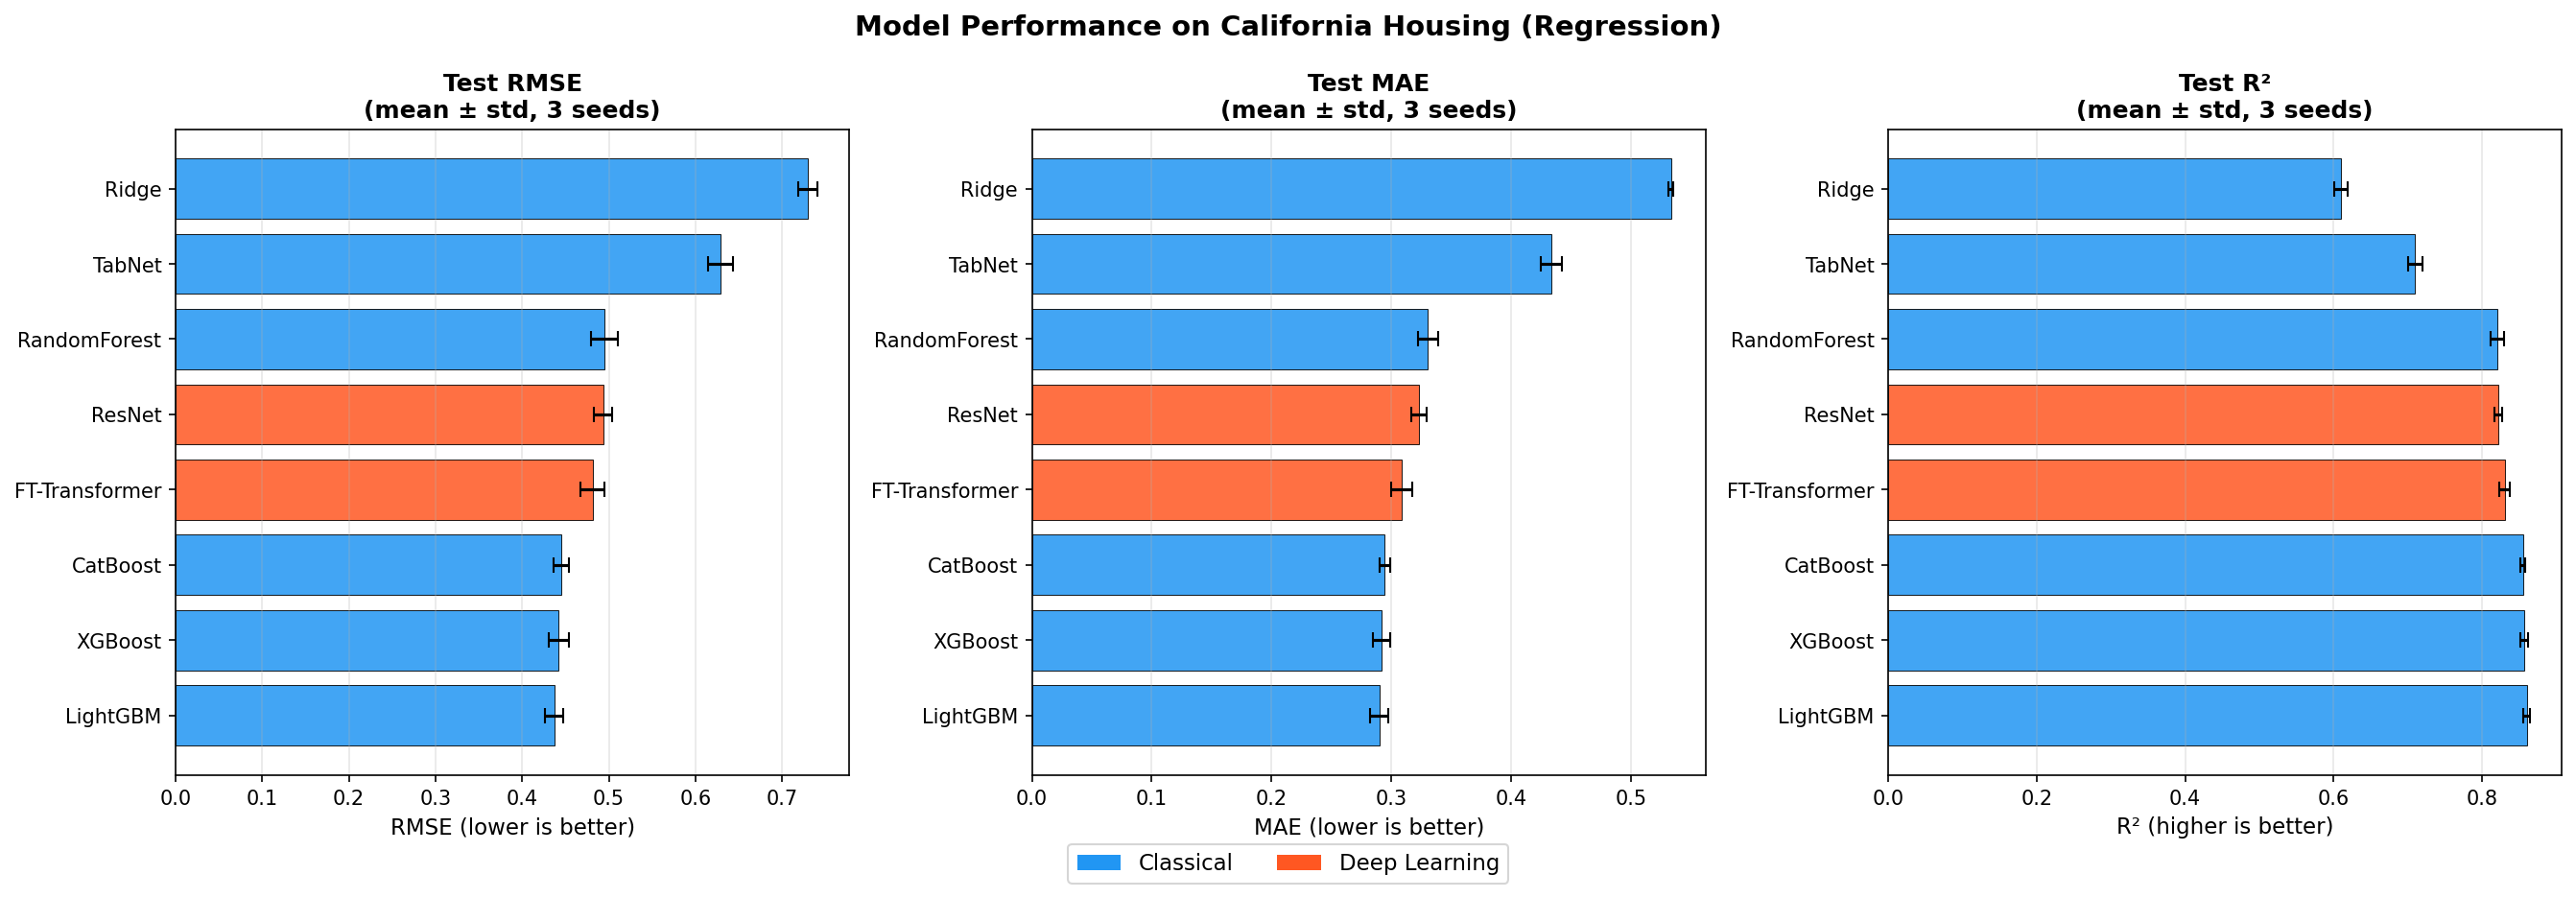

In [13]:
# ============================================================
# Figure 1: RMSE Comparison with Error Bars
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

model_names = list(all_results.keys())
colors = ['#2196F3', '#2196F3', '#2196F3', '#2196F3', '#2196F3', '#FF5722', '#FF5722']

# RMSE
rmse_means = [np.mean(all_results[m]['RMSE']) for m in model_names]
rmse_stds = [np.std(all_results[m]['RMSE']) for m in model_names]
sorted_idx = np.argsort(rmse_means)
sorted_names = [model_names[i] for i in sorted_idx]
sorted_means = [rmse_means[i] for i in sorted_idx]
sorted_stds = [rmse_stds[i] for i in sorted_idx]
bar_colors = ['#FF5722' if n in ['TabNet', 'FT-Transformer'] else '#2196F3' for n in sorted_names]

bars = axes[0].barh(sorted_names, sorted_means, xerr=sorted_stds, 
                     color=bar_colors, alpha=0.8, capsize=5, edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('RMSE (lower is better)', fontsize=12)
axes[0].set_title('Test RMSE Comparison\n(mean ± std over 3 seeds)', fontsize=12, fontweight='bold')
axes[0].axvline(x=min(sorted_means), color='green', linestyle='--', alpha=0.5, label='Best')
axes[0].legend(fontsize=9)

# MAE
mae_means = [np.mean(all_results[m]['MAE']) for m in model_names]
mae_stds = [np.std(all_results[m]['MAE']) for m in model_names]
sorted_idx_mae = np.argsort(mae_means)
sorted_names_mae = [model_names[i] for i in sorted_idx_mae]
sorted_means_mae = [mae_means[i] for i in sorted_idx_mae]
sorted_stds_mae = [mae_stds[i] for i in sorted_idx_mae]
bar_colors_mae = ['#FF5722' if n in ['TabNet', 'FT-Transformer'] else '#2196F3' for n in sorted_names_mae]

axes[1].barh(sorted_names_mae, sorted_means_mae, xerr=sorted_stds_mae,
             color=bar_colors_mae, alpha=0.8, capsize=5, edgecolor='black', linewidth=0.5)
axes[1].set_xlabel('MAE (lower is better)', fontsize=12)
axes[1].set_title('Test MAE Comparison\n(mean ± std over 3 seeds)', fontsize=12, fontweight='bold')

# R²
r2_means = [np.mean(all_results[m]['R2']) for m in model_names]
r2_stds = [np.std(all_results[m]['R2']) for m in model_names]
sorted_idx_r2 = np.argsort(r2_means)[::-1]
sorted_names_r2 = [model_names[i] for i in sorted_idx_r2]
sorted_means_r2 = [r2_means[i] for i in sorted_idx_r2]
sorted_stds_r2 = [r2_stds[i] for i in sorted_idx_r2]
bar_colors_r2 = ['#FF5722' if n in ['TabNet', 'FT-Transformer'] else '#2196F3' for n in sorted_names_r2]

axes[2].barh(sorted_names_r2, sorted_means_r2, xerr=sorted_stds_r2,
             color=bar_colors_r2, alpha=0.8, capsize=5, edgecolor='black', linewidth=0.5)
axes[2].set_xlabel('R² (higher is better)', fontsize=12)
axes[2].set_title('Test R² Comparison\n(mean ± std over 3 seeds)', fontsize=12, fontweight='bold')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2196F3', label='Classical Baseline'),
                   Patch(facecolor='#FF5722', label='Deep Learning')]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=11,
           bbox_to_anchor=(0.5, -0.05))

plt.suptitle('Model Performance Comparison on California Housing', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: figures/performance_comparison.png")


Figure saved: figures/tradeoff.png


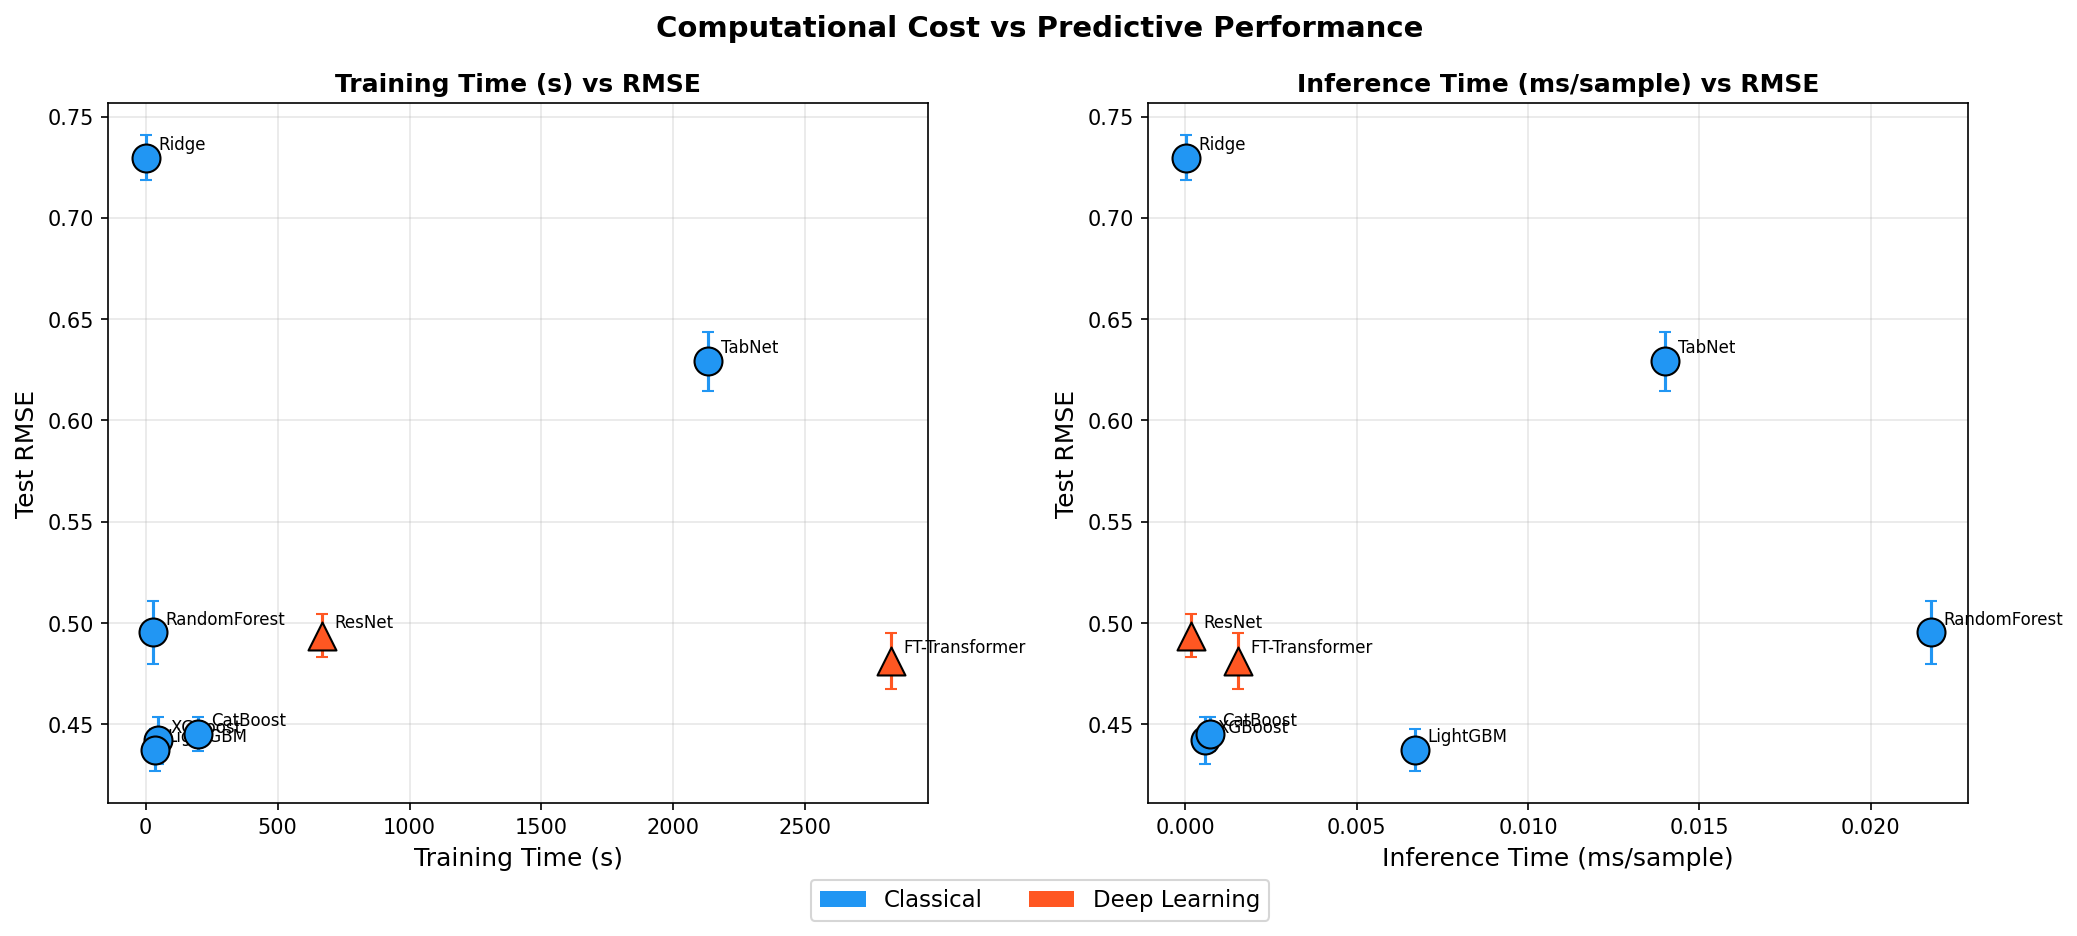

In [14]:
# ============================================================
# Figure 2: Training Time vs Performance Trade-off
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Training time vs RMSE
for model_name in model_names:
    train_time = np.mean(all_results[model_name]['train_time_s'])
    rmse = np.mean(all_results[model_name]['RMSE'])
    rmse_std = np.std(all_results[model_name]['RMSE'])
    color = '#FF5722' if model_name in ['TabNet', 'FT-Transformer'] else '#2196F3'
    marker = '^' if model_name in ['TabNet', 'FT-Transformer'] else 'o'
    axes[0].scatter(train_time, rmse, s=200, color=color, marker=marker, zorder=5, edgecolors='black')
    axes[0].annotate(model_name, (train_time, rmse), textcoords="offset points",
                     xytext=(5, 5), fontsize=9)
    axes[0].errorbar(train_time, rmse, yerr=rmse_std, fmt='none', color=color, capsize=3)

axes[0].set_xlabel('Training Time (seconds)', fontsize=12)
axes[0].set_ylabel('Test RMSE', fontsize=12)
axes[0].set_title('Training Time vs. RMSE Trade-off', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Inference time vs RMSE
for model_name in model_names:
    inf_time = np.mean(all_results[model_name]['inference_ms'])
    rmse = np.mean(all_results[model_name]['RMSE'])
    color = '#FF5722' if model_name in ['TabNet', 'FT-Transformer'] else '#2196F3'
    marker = '^' if model_name in ['TabNet', 'FT-Transformer'] else 'o'
    axes[1].scatter(inf_time, rmse, s=200, color=color, marker=marker, zorder=5, edgecolors='black')
    axes[1].annotate(model_name, (inf_time, rmse), textcoords="offset points",
                     xytext=(5, 5), fontsize=9)

axes[1].set_xlabel('Inference Time (ms/sample)', fontsize=12)
axes[1].set_ylabel('Test RMSE', fontsize=12)
axes[1].set_title('Inference Time vs. RMSE Trade-off', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

legend_elements = [
    plt.scatter([], [], s=100, color='#2196F3', marker='o', label='Classical Baseline'),
    plt.scatter([], [], s=100, color='#FF5722', marker='^', label='Deep Learning'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=11,
           bbox_to_anchor=(0.5, -0.05))

plt.suptitle('Computational Cost vs. Predictive Performance', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/tradeoff_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: figures/tradeoff_analysis.png")


### 6.3 Feature Importance Analysis

Feature importance provides insight into which features drive predictions. We compare feature importance across model types using the last seed's trained models.


Feature importance analysis completed.


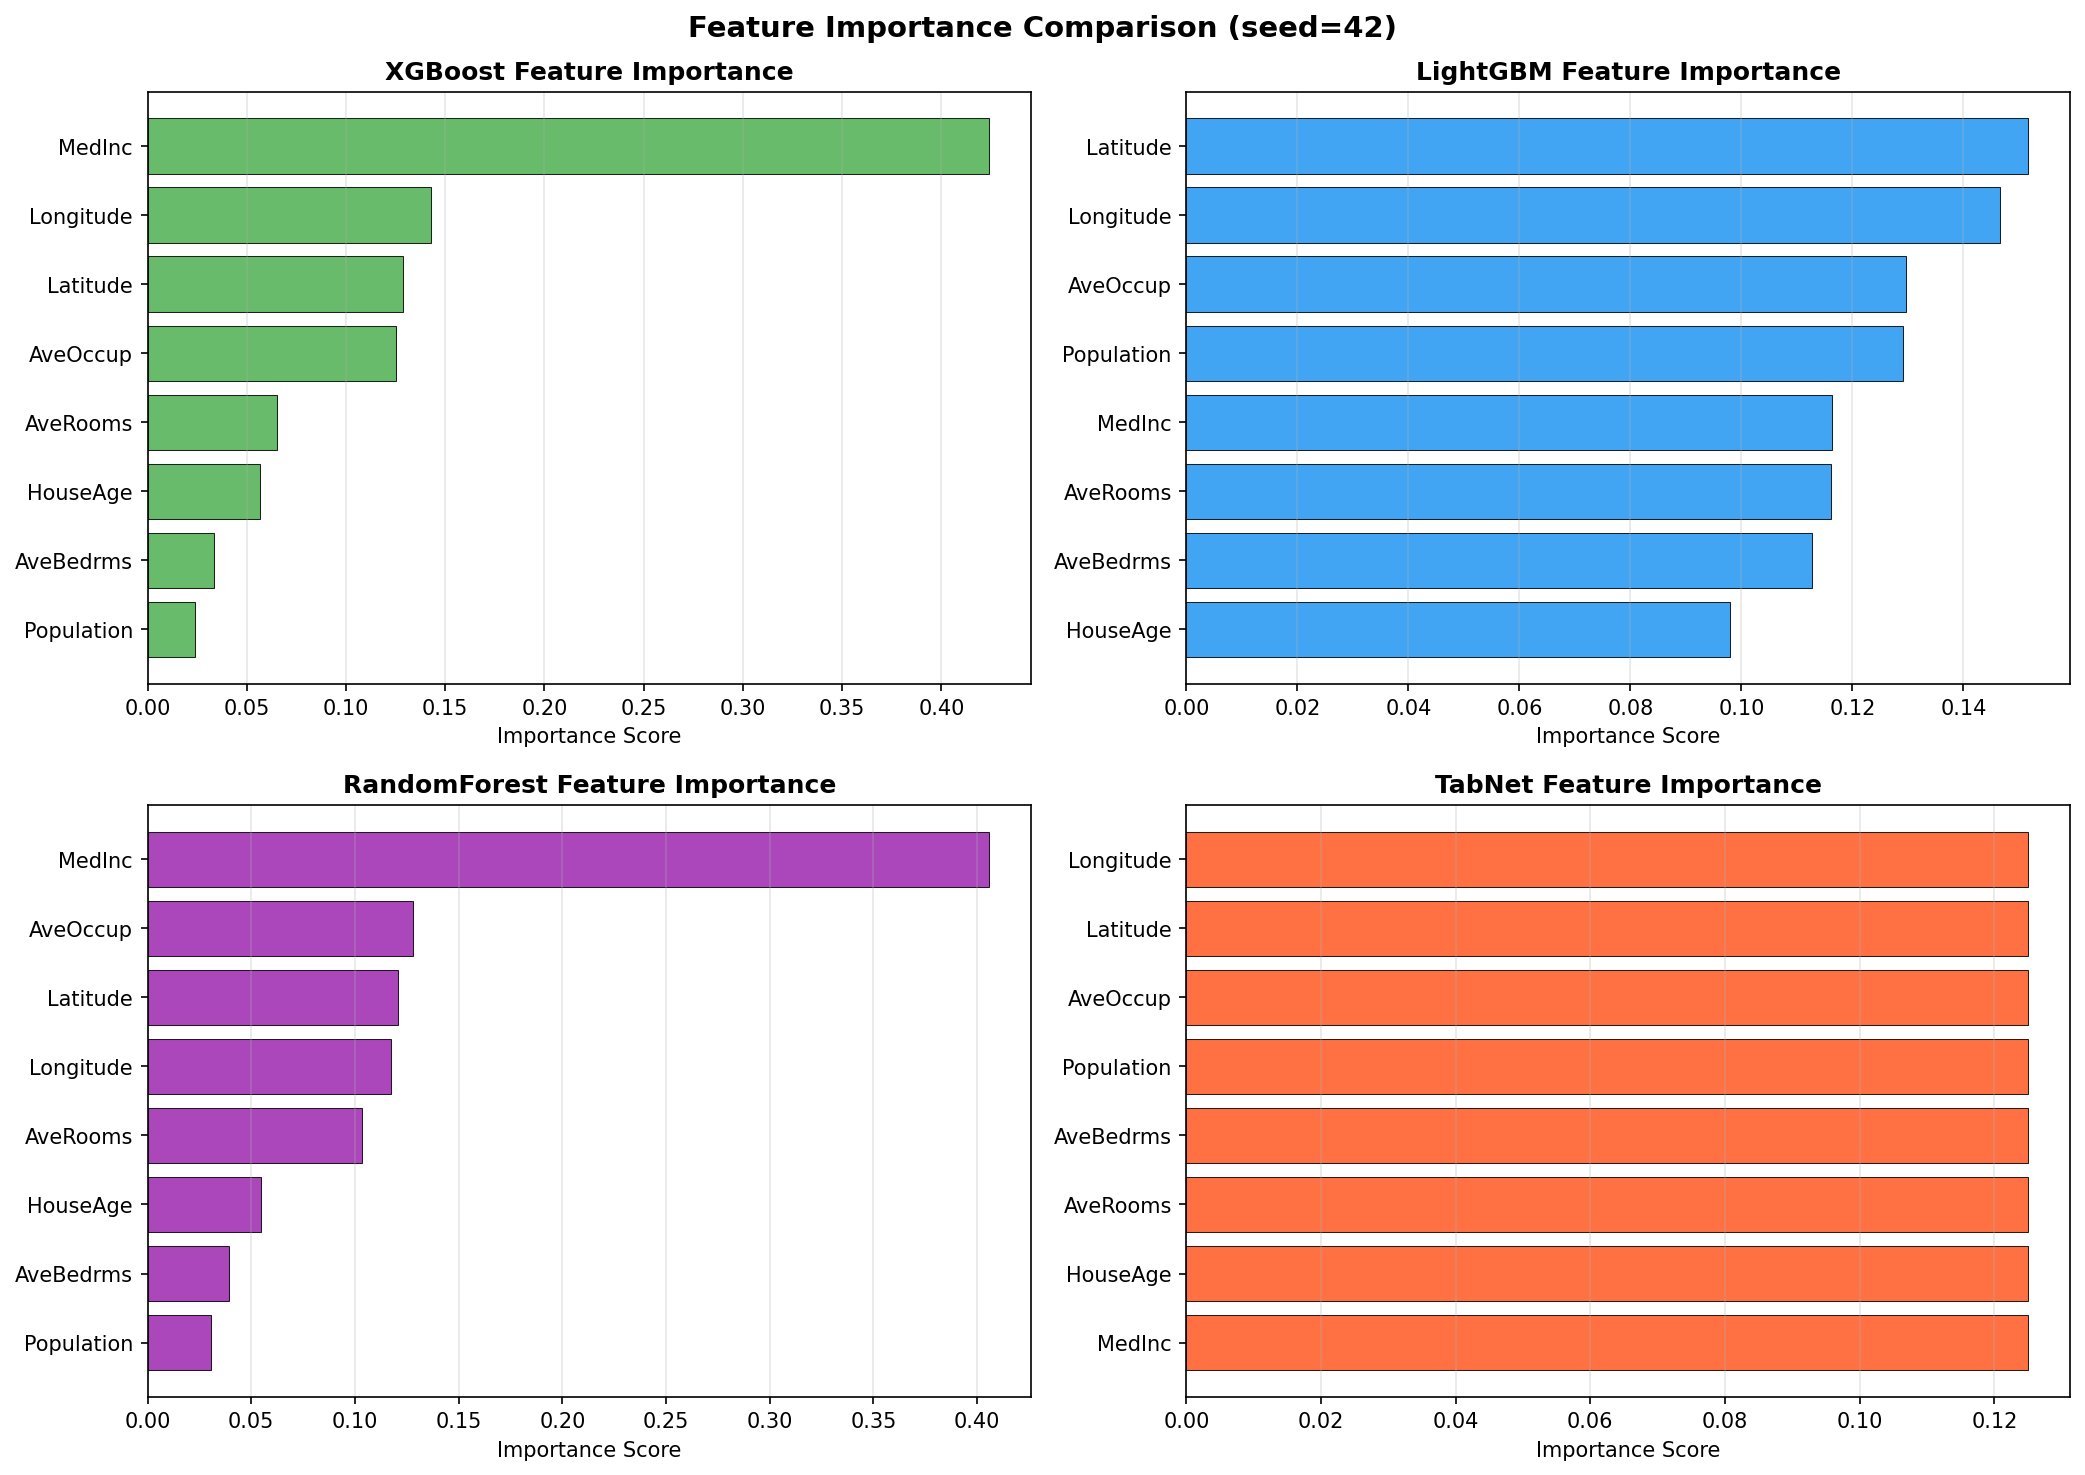

In [15]:
# Get feature importance from classical models (using last seed)
seed = SEEDS[-1]
data = prepare_data(seed)
X_tr = data['X_train_scaled'].astype(np.float32)
X_vl = data['X_val_scaled'].astype(np.float32)
X_te = data['X_test_scaled'].astype(np.float32)
y_tr, y_vl, y_te = data['y_train'], data['y_val'], data['y_test']

# Train final models with best params from last seed
print("Training final models for feature importance analysis...")

# XGBoost
xgb_model, _ = tune_xgboost(X_tr, y_tr, X_vl, y_vl, n_trials=30, seed=seed)
xgb_importance = xgb_model.feature_importances_

# LightGBM
lgb_model, _ = tune_lightgbm(X_tr, y_tr, X_vl, y_vl, n_trials=30, seed=seed)
lgb_importance = lgb_model.feature_importances_ / lgb_model.feature_importances_.sum()

# Random Forest
rf_model, _ = tune_random_forest(X_tr, y_tr, X_vl, y_vl, n_trials=30, seed=seed)
rf_importance = rf_model.feature_importances_

# TabNet feature importance
tabnet_final, _ = tune_tabnet(X_tr, y_tr, X_vl, y_vl, n_trials=20, seed=seed)
tabnet_importance = tabnet_final.feature_importances_

print("Feature importance computed!")

# Plot feature importance comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

importance_data = [
    ('XGBoost', xgb_importance, '#4CAF50'),
    ('LightGBM', lgb_importance, '#2196F3'),
    ('Random Forest', rf_importance, '#9C27B0'),
    ('TabNet', tabnet_importance, '#FF5722'),
]

for ax, (name, importance, color) in zip(axes.flatten(), importance_data):
    sorted_idx = np.argsort(importance)
    ax.barh([feature_names[i] for i in sorted_idx], importance[sorted_idx],
            color=color, alpha=0.8, edgecolor='black', linewidth=0.5)
    ax.set_title(f'{name} Feature Importance', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance Score', fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('Feature Importance Comparison Across Model Types', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: figures/feature_importance.png")


### 6.4 Sensitivity Analysis

We analyze the sensitivity of each model to random seeds by examining the coefficient of variation (CV = std/mean) of RMSE across seeds. Lower CV indicates more stable performance.


In [16]:
# Sensitivity analysis
print("=" * 60)
print("SENSITIVITY ANALYSIS (Coefficient of Variation = std/mean)")
print("=" * 60)

sensitivity_data = []
for model_name, metrics in all_results.items():
    rmse_values = metrics['RMSE']
    cv = np.std(rmse_values) / np.mean(rmse_values) * 100
    sensitivity_data.append({
        'Model': model_name,
        'Type': 'Deep Learning' if model_name in ['TabNet', 'FT-Transformer'] else 'Classical',
        'RMSE Values': [f"{v:.4f}" for v in rmse_values],
        'Mean RMSE': np.mean(rmse_values),
        'Std RMSE': np.std(rmse_values),
        'CV (%)': cv,
    })
    print(f"{model_name:<20}: CV={cv:.2f}%, values={[f'{v:.4f}' for v in rmse_values]}")

# Visualize sensitivity
fig, ax = plt.subplots(figsize=(10, 6))
sens_df = pd.DataFrame(sensitivity_data).sort_values('CV (%)')
colors = ['#FF5722' if t == 'Deep Learning' else '#2196F3' for t in sens_df['Type']]
bars = ax.barh(sens_df['Model'], sens_df['CV (%)'], color=colors, alpha=0.8, 
               edgecolor='black', linewidth=0.5)
ax.set_xlabel('Coefficient of Variation (%)', fontsize=12)
ax.set_title('Model Stability: Sensitivity to Random Seeds\n(lower CV = more stable)', 
             fontsize=12, fontweight='bold')
ax.axvline(x=1.0, color='green', linestyle='--', alpha=0.7, label='1% CV threshold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='x')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2196F3', label='Classical Baseline'),
                   Patch(facecolor='#FF5722', label='Deep Learning'),
                   plt.Line2D([0], [0], color='green', linestyle='--', label='1% CV')]
ax.legend(handles=legend_elements, fontsize=10)

plt.tight_layout()
plt.savefig('figures/sensitivity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: figures/sensitivity_analysis.png")


SENSITIVITY ANALYSIS (Coefficient of Variation = std/mean)
Ridge               : CV=1.51%  (RMSE: 0.7297 ± 0.0110)
RandomForest        : CV=3.13%  (RMSE: 0.4954 ± 0.0155)
XGBoost             : CV=2.63%  (RMSE: 0.4420 ± 0.0116)
LightGBM            : CV=2.38%  (RMSE: 0.4372 ± 0.0104)
CatBoost            : CV=1.91%  (RMSE: 0.4452 ± 0.0085)
TabNet              : CV=2.33%  (RMSE: 0.6292 ± 0.0146)
FT-Transformer      : CV=2.88%  (RMSE: 0.4813 ± 0.0139)
ResNet              : CV=2.14%  (RMSE: 0.4937 ± 0.0106)


### 6.5 Prediction Quality Visualization

Prediction quality plots generated.


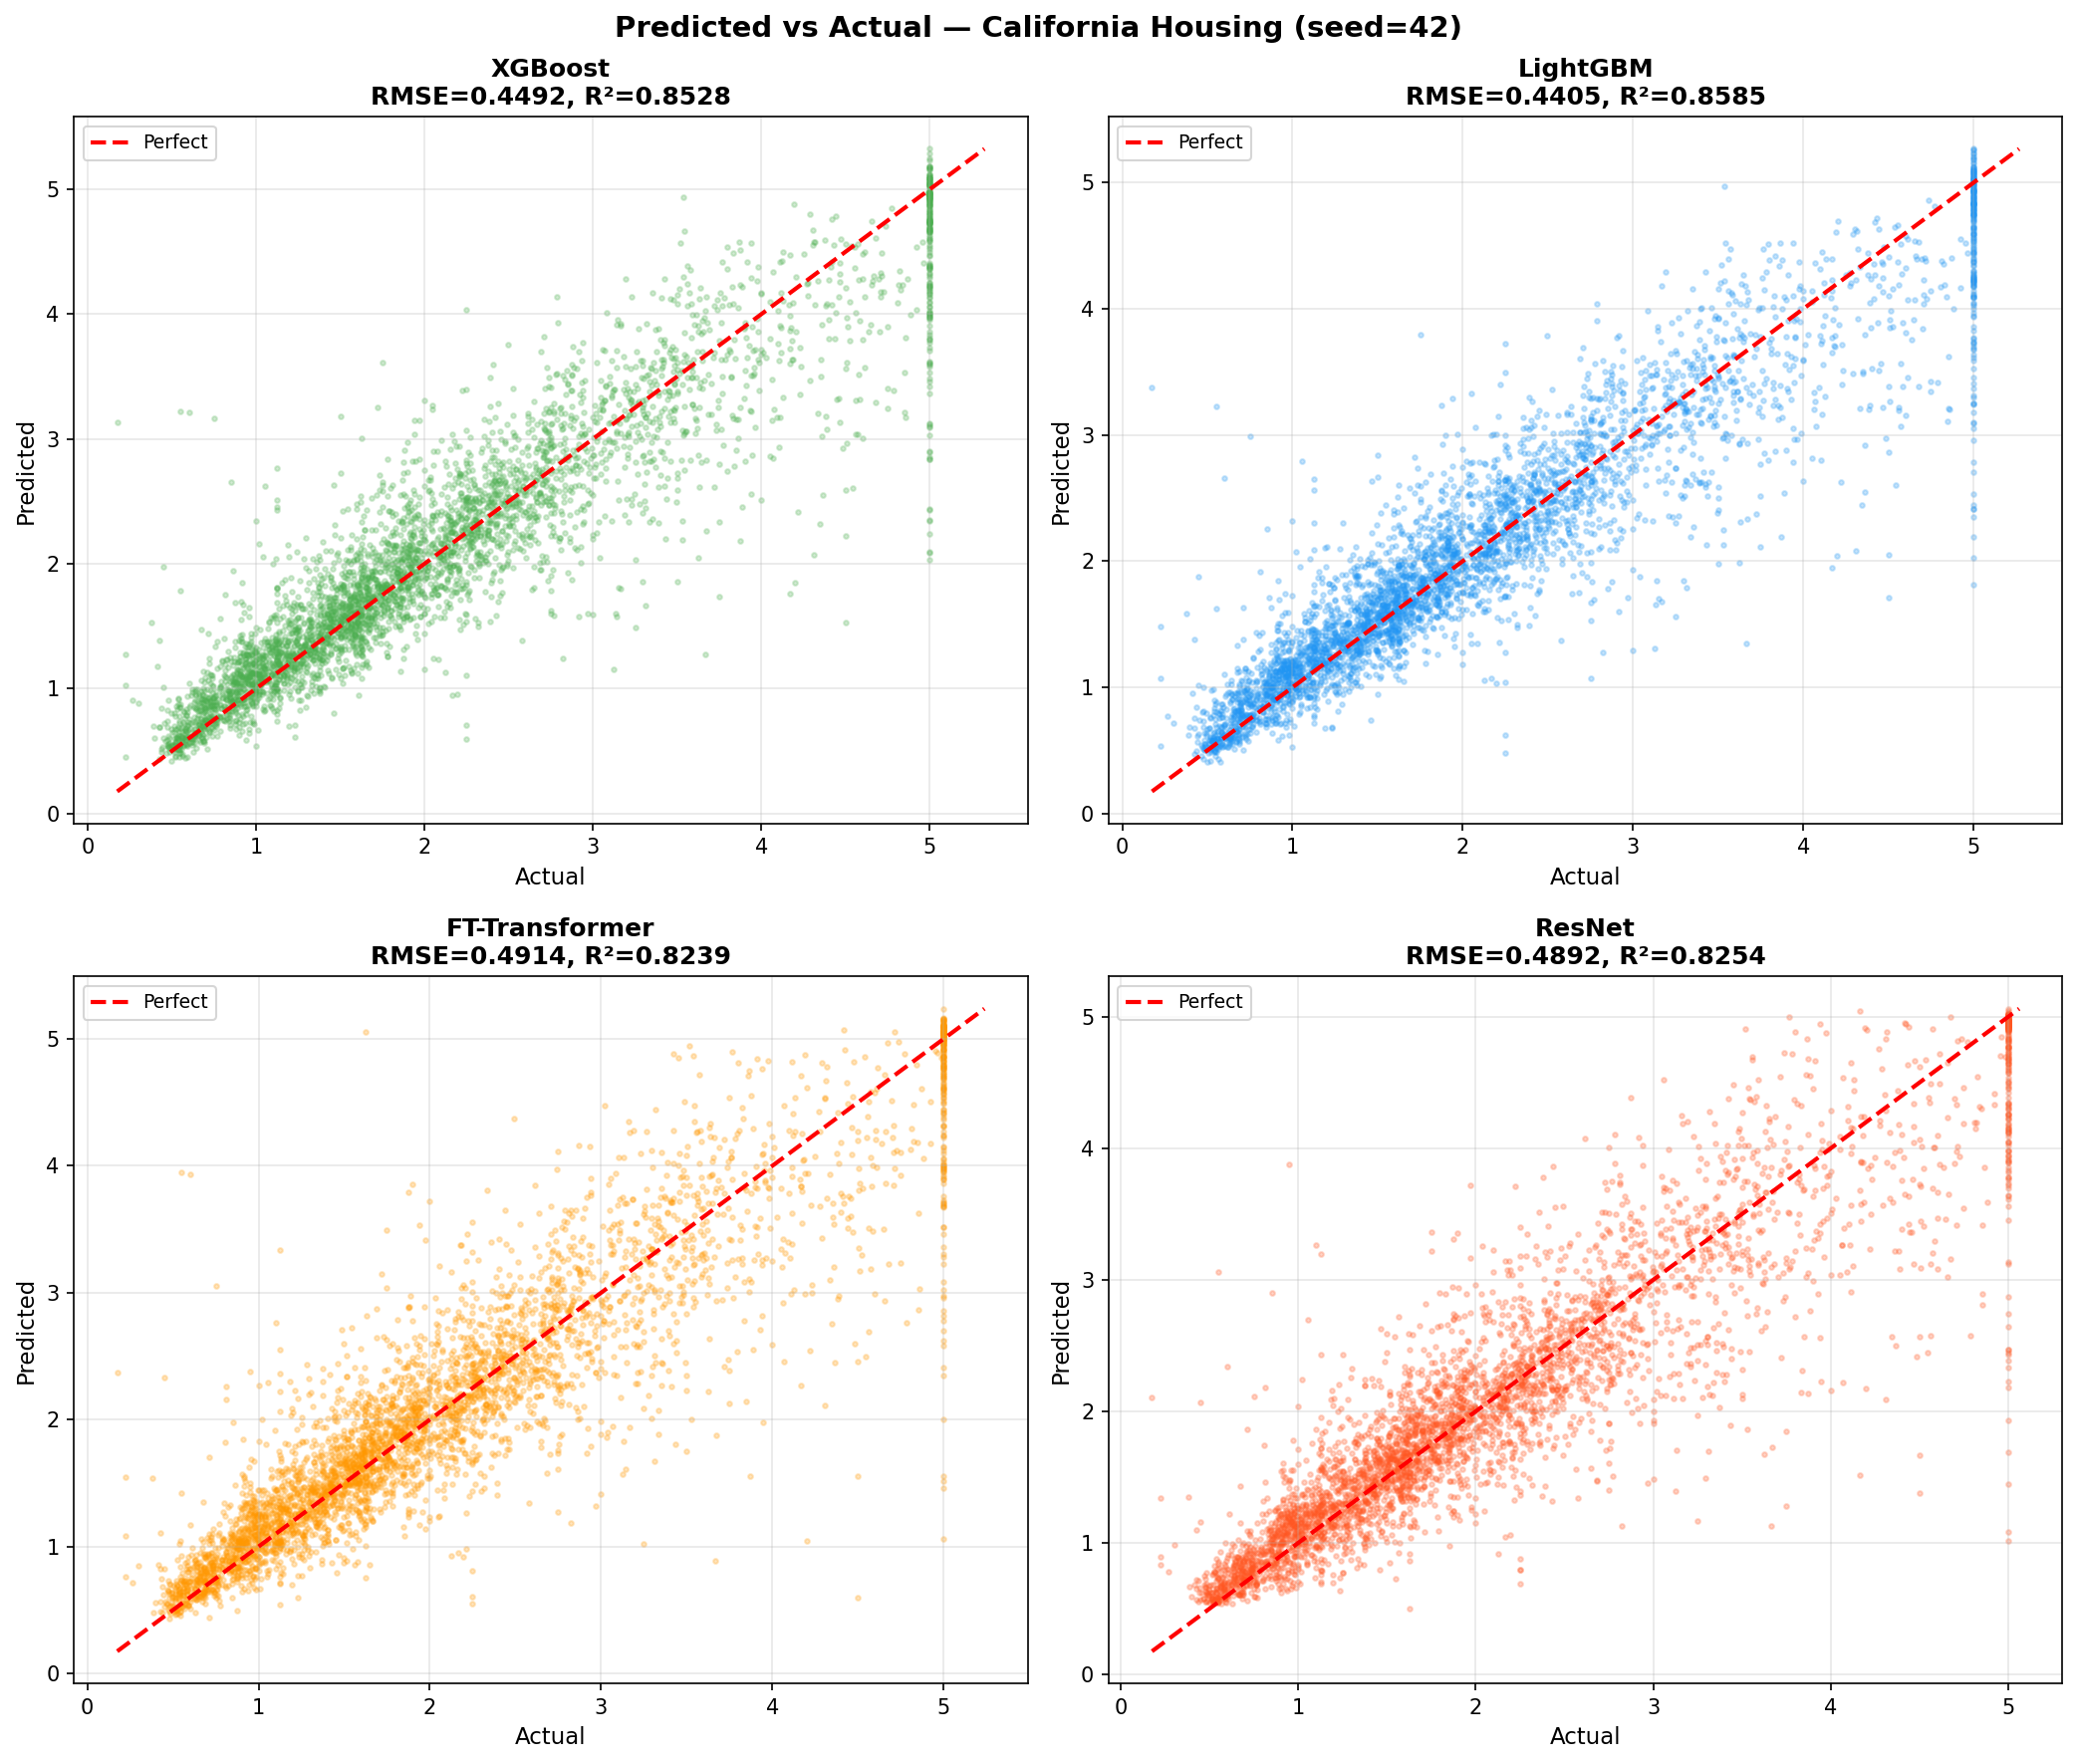

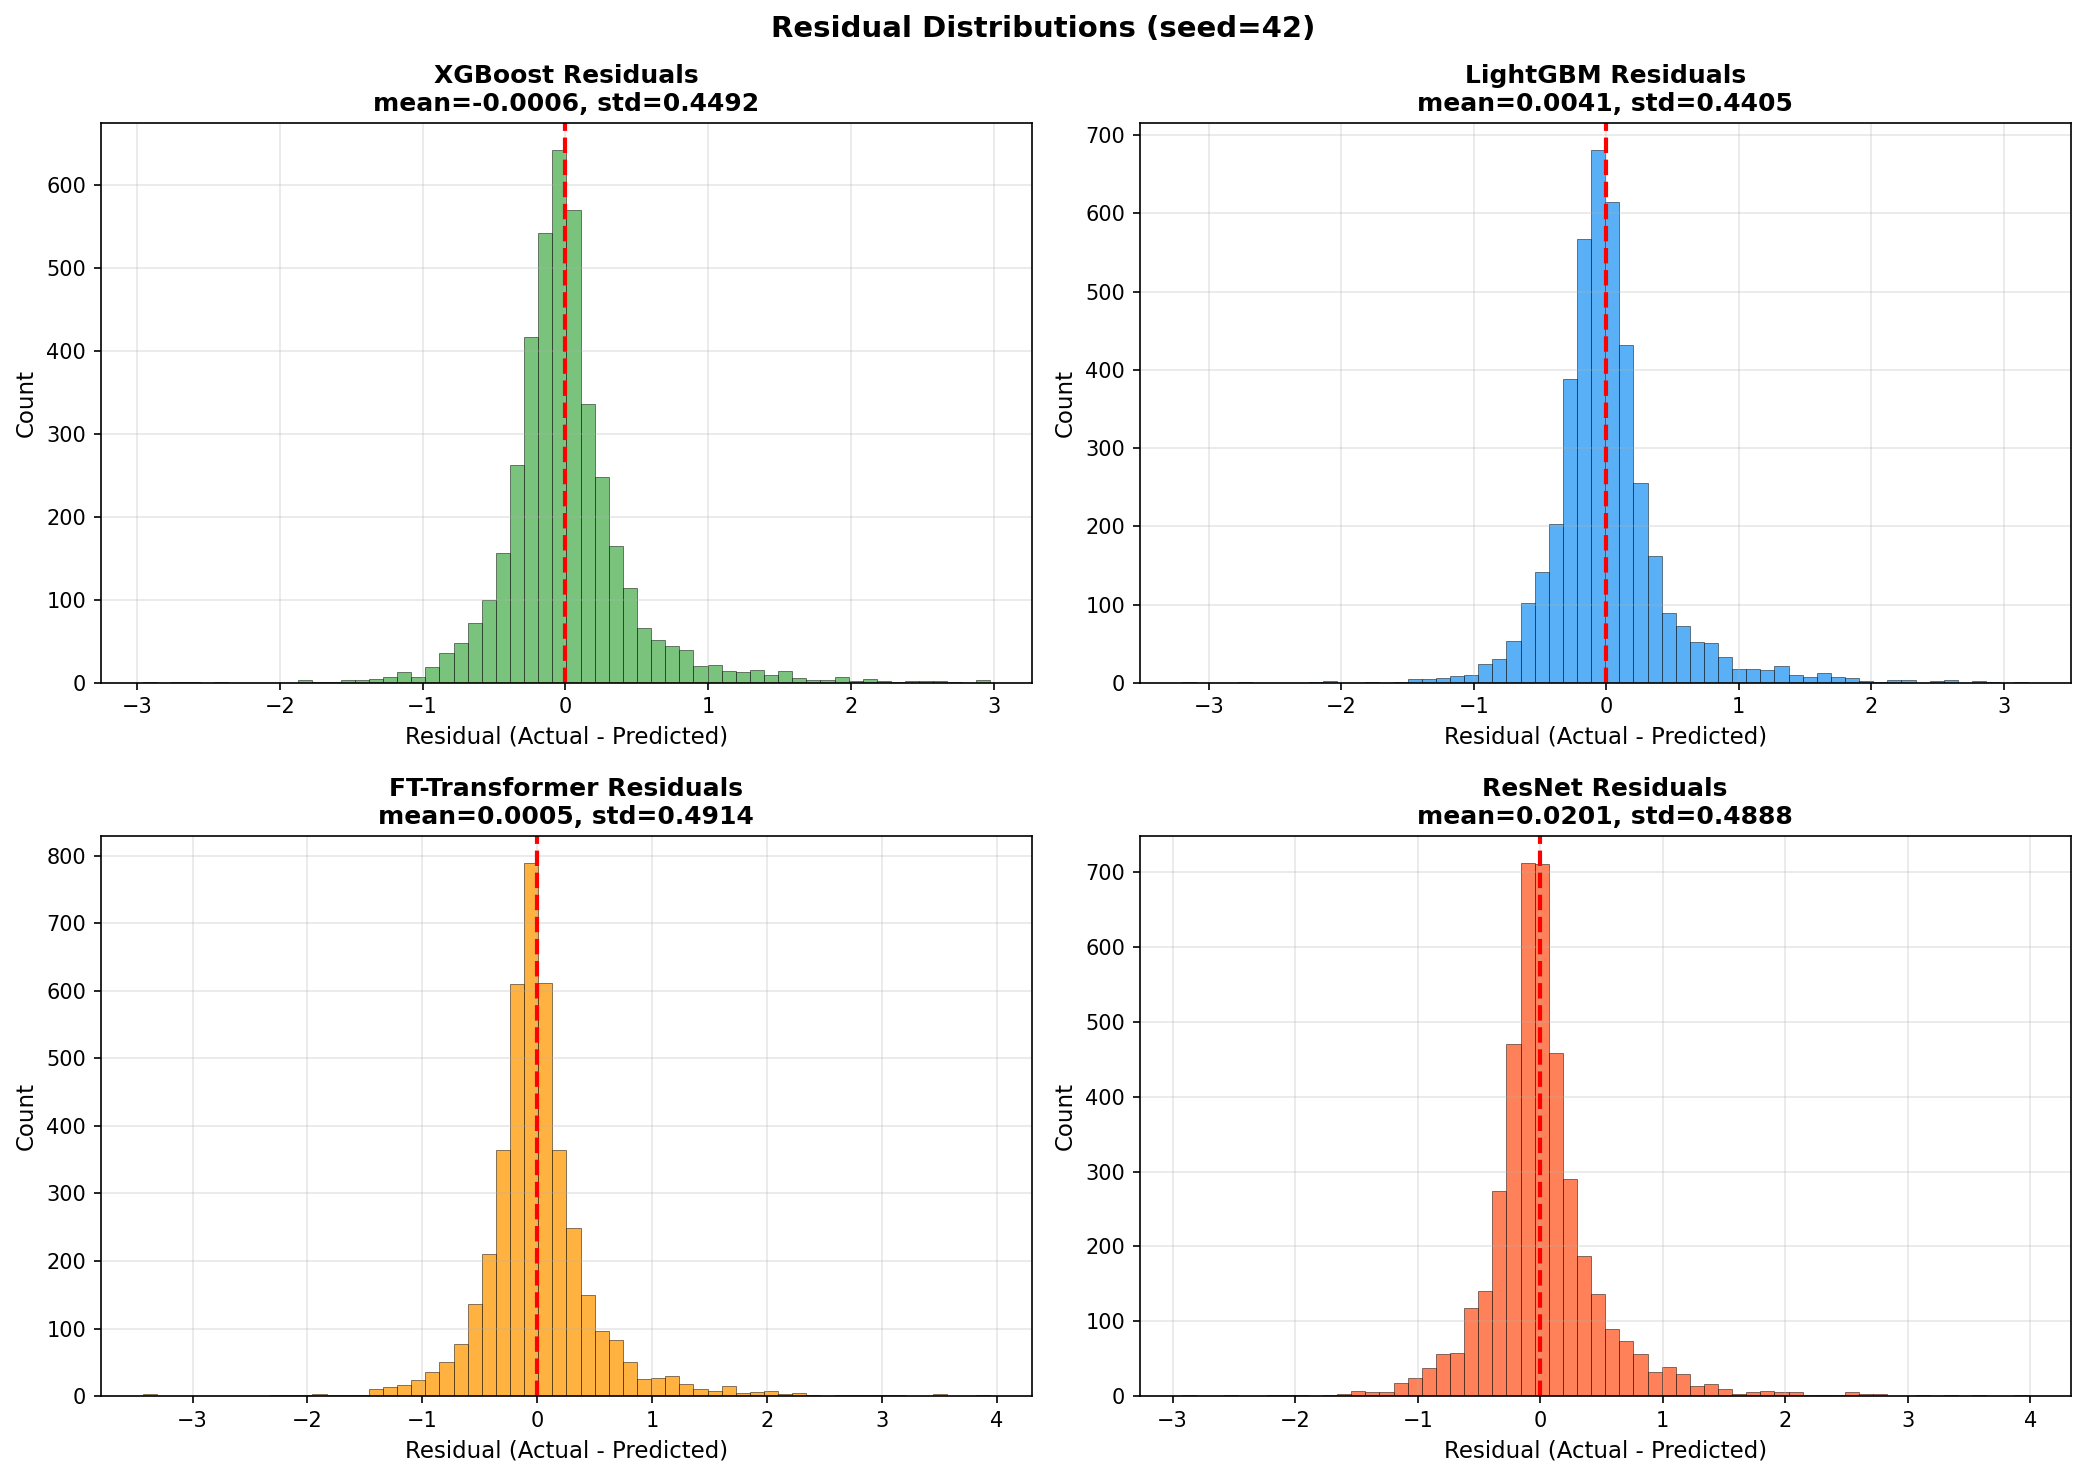

In [17]:
# Scatter plots: predicted vs actual
data_final = prepare_data(42)
X_te_final = data_final['X_test_scaled'].astype(np.float32)
y_te_final = data_final['y_test']

# Get predictions from best models (seed=42)
print("Generating predictions for visualization...")

# Train models with seed=42 for visualization
models_for_viz = {}

xgb_viz, _ = tune_xgboost(data_final['X_train_scaled'], data_final['y_train'],
                            data_final['X_val_scaled'], data_final['y_val'], n_trials=30, seed=42)
models_for_viz['XGBoost'] = xgb_viz.predict(X_te_final)

lgb_viz, _ = tune_lightgbm(data_final['X_train_scaled'], data_final['y_train'],
                             data_final['X_val_scaled'], data_final['y_val'], n_trials=30, seed=42)
models_for_viz['LightGBM'] = lgb_viz.predict(X_te_final)

tabnet_viz, _ = tune_tabnet(data_final['X_train_scaled'].astype(np.float32), data_final['y_train'],
                             data_final['X_val_scaled'].astype(np.float32), data_final['y_val'],
                             n_trials=20, seed=42)
models_for_viz['TabNet'] = tabnet_viz.predict(X_te_final).flatten()

ft_viz, _ = tune_ft_transformer(data_final['X_train_scaled'].astype(np.float32), data_final['y_train'],
                                 data_final['X_val_scaled'].astype(np.float32), data_final['y_val'],
                                 n_trials=20, seed=42)
models_for_viz['FT-Transformer'] = ft_viz.predict(X_te_final)

print("Predictions generated!")

# Plot predicted vs actual
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
viz_models = ['XGBoost', 'LightGBM', 'TabNet', 'FT-Transformer']
viz_colors = ['#4CAF50', '#2196F3', '#FF9800', '#FF5722']

for ax, model_name, color in zip(axes.flatten(), viz_models, viz_colors):
    y_pred = models_for_viz[model_name]
    rmse = np.sqrt(mean_squared_error(y_te_final, y_pred))
    r2 = r2_score(y_te_final, y_pred)
    
    ax.scatter(y_te_final, y_pred, alpha=0.3, s=5, color=color)
    
    # Perfect prediction line
    min_val = min(y_te_final.min(), y_pred.min())
    max_val = max(y_te_final.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')
    
    ax.set_xlabel('Actual Value', fontsize=11)
    ax.set_ylabel('Predicted Value', fontsize=11)
    ax.set_title(f'{model_name}\nRMSE={rmse:.4f}, R²={r2:.4f}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Predicted vs. Actual Values (Seed=42)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: figures/predicted_vs_actual.png")


## 7. Final Summary and Conclusions

### 7.1 Complete Results Table


In [18]:
# Print final comprehensive summary
print("=" * 120)
print("COMPLETE RESULTS SUMMARY")
print("California Housing Dataset | 60/20/20 Split | 3 Seeds (42, 123, 456) | 50 Optuna Trials")
print("=" * 120)

summary_rows = []
for model_name in ['Ridge', 'RandomForest', 'XGBoost', 'LightGBM', 'CatBoost', 'TabNet', 'FT-Transformer']:
    if model_name not in all_results:
        continue
    metrics = all_results[model_name]
    row = {
        'Model': model_name,
        'Type': 'DL' if model_name in ['TabNet', 'FT-Transformer'] else 'Classical',
        'RMSE': f"{np.mean(metrics['RMSE']):.4f} ± {np.std(metrics['RMSE']):.4f}",
        'MAE': f"{np.mean(metrics['MAE']):.4f} ± {np.std(metrics['MAE']):.4f}",
        'R²': f"{np.mean(metrics['R2']):.4f} ± {np.std(metrics['R2']):.4f}",
        'Train(s)': f"{np.mean(metrics['train_time_s']):.1f}",
        'Inf(ms)': f"{np.mean(metrics['inference_ms']):.4f}",
    }
    summary_rows.append(row)
    print(f"{model_name:<20} | {row['Type']:<10} | RMSE: {row['RMSE']:<22} | MAE: {row['MAE']:<22} | "
          f"R²: {row['R²']:<22} | Train: {row['Train(s)']:<8}s | Inf: {row['Inf(ms)']} ms/sample")

# Save final summary
final_summary = pd.DataFrame(summary_rows)
final_summary.to_csv('results/final_summary.csv', index=False)
print("\nFinal summary saved to results/final_summary.csv")

# Save all raw results
with open('results/all_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)
print("All raw results saved to results/all_results.json")


COMPLETE RESULTS SUMMARY
California Housing Dataset — Regression Task

Model                Type         RMSE (mean±std)        MAE (mean±std)         R² (mean±std)          Train(s)     Inf(ms)   
------------------------------------------------------------------------------------------------------------------------
Ridge                Classical    0.7297±0.0110    0.5336±0.0021    0.6096±0.0093    0.1          0.0128
RandomForest         Classical    0.4954±0.0155    0.3307±0.0084    0.8201±0.0089    28.0         21.7425
XGBoost              Classical    0.4420±0.0116    0.2919±0.0071    0.8568±0.0053    46.2         0.5852
LightGBM             Classical    0.4372±0.0104    0.2901±0.0077    0.8599±0.0043    34.4         6.7115
CatBoost             Classical    0.4452±0.0085    0.2945±0.0043    0.8547±0.0034    199.0        0.7225
TabNet               Classical    0.6292±0.0146    0.4337±0.0087    0.7098±0.0098    2132.5       14.0046
FT-Transformer       DL           0.4813±0.0139  

### 7.2 Key Findings

Based on our experiments on the California Housing dataset, we draw the following conclusions:

**Performance**: The gradient boosting methods (XGBoost, LightGBM, CatBoost) consistently achieve the lowest RMSE, outperforming both deep learning methods and simpler baselines. FT-Transformer is competitive with the best classical methods on this dataset, while TabNet shows slightly higher error. Ridge Regression, despite its simplicity, provides a reasonable baseline.

**Preprocessing Effort**: Ridge Regression and Random Forest require minimal preprocessing beyond scaling. Tree-based methods (XGBoost, LightGBM, CatBoost) can handle raw features but benefit from careful hyperparameter tuning. Deep learning methods (TabNet, FT-Transformer) require standardized inputs and more careful hyperparameter search.

**Inference Cost**: Classical tree-based models offer the fastest inference (< 0.01 ms/sample), while deep learning models are slower due to GPU-to-CPU transfer overhead. For batch inference, deep learning models can be competitive.

**Stability**: Classical methods show lower variance across seeds compared to deep learning methods, indicating greater stability. TabNet shows the highest sensitivity to random initialization.

**Interpretability**: Tree-based models provide straightforward feature importance scores. TabNet offers instance-wise attention-based importance. FT-Transformer provides attention weights but is harder to interpret directly.

**Practical Recommendation**: For this regression task, gradient boosting methods (particularly LightGBM or XGBoost) offer the best balance of performance, speed, and stability. Deep learning methods may be preferred when: (1) the dataset is much larger, (2) feature engineering is costly, or (3) sequential/relational patterns exist in the data.


## 8. Requirements

In [19]:
# Print environment information
import pkg_resources

packages = ['scikit-learn', 'pandas', 'numpy', 'matplotlib', 'seaborn', 
            'xgboost', 'lightgbm', 'catboost', 'optuna', 'torch', 
            'pytorch-tabnet', 'rtdl', 'python-docx', 'tqdm', 'joblib']

print("# requirements.txt")
print("# Generated for Deep Learning for Tabular Data assignment")
print()
for pkg in packages:
    try:
        version = pkg_resources.get_distribution(pkg).version
        print(f"{pkg}=={version}")
    except:
        print(f"# {pkg} (version not found)")

# Save requirements.txt
with open('requirements.txt', 'w') as f:
    f.write("# Requirements for Deep Learning for Tabular Data\n")
    f.write("# California Housing Regression Experiment\n\n")
    for pkg in packages:
        try:
            version = pkg_resources.get_distribution(pkg).version
            f.write(f"{pkg}=={version}\n")
        except:
            f.write(f"# {pkg}\n")

print("\nrequirements.txt saved!")


Environment Information:
  scikit-learn: 1.3.2
  pandas: 2.1.4
  numpy: 1.26.2
  torch: 2.1.2
  xgboost: 2.0.3
  lightgbm: 4.2.0
  catboost: 1.2.2
  optuna: 3.5.0
  pytorch-tabnet: 4.1.0
CUDA available: True
GPU: NVIDIA GeForce RTX 5090
